# JEPA V5.1 - Hidden Patch Prediction

## Goal

Instead of splitting an image into two halves, we:

1. Take a full image.
2. Hide a small patch from the image.
3. Use the visible pixels (context) to predict the representation of the hidden patch.
4. Compare the predicted representation with the actual representation produced by the target encoder.

This is closer to the JEPA idea:

**Context → Representation → Predicted Target Representation**


# 1. Imports

In [43]:
import torch
import torch.nn as nn

import torch.nn.functional as F

from torchvision import datasets
from torchvision import transforms

import matplotlib.pyplot as plt

# 2. Dataset Setup

### Previous Version (V4)
- Split image into Context and Target.
- Context = one region.
- Target = another region.

### Current Version (V5)
- Use the entire image.
- Hide a small patch.
- Visible area becomes the context.
- Hidden patch becomes the target.


In [44]:
transform = transforms.ToTensor()

# change 1, from v2
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform=transform,
)

# 3. Load and Visualize an Image

In [45]:
image, _ = dataset[0]

[]

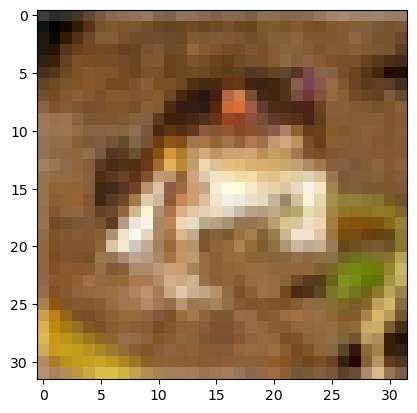

In [46]:
plt.imshow(image.permute(1, 2, 0))
plt.plot()

# 4. Create Context and Target

Target:
- Hidden 8×8 patch.

Context:
- Original image with the target patch replaced by zeros.


In [47]:
target = image[:, 12:20, 12:20]

context = image.clone()
context[:, 12:20, 12:20] = 0

In [48]:
print(context.shape)
print(target.shape)

torch.Size([3, 32, 32])
torch.Size([3, 8, 8])


# 5. Visualize Context and Target

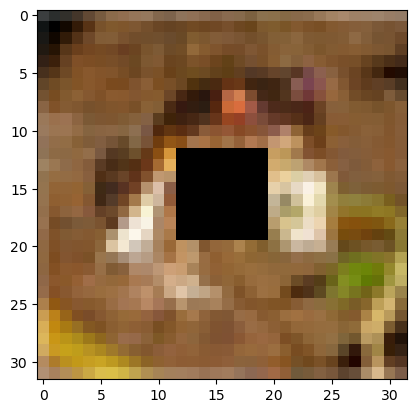

In [49]:
plt.imshow(context.permute(1, 2, 0))
plt.show()

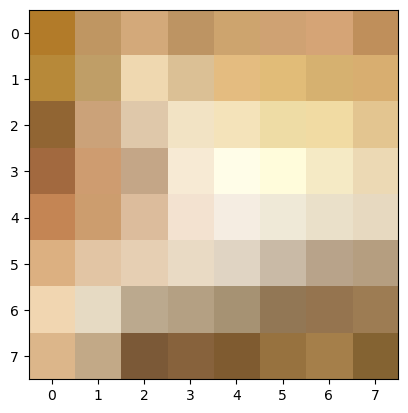

In [50]:
plt.imshow(target.permute(1, 2, 0))
plt.show()

# 6. Add Batch Dimension

PyTorch linear layers expect batched input.


In [51]:
context = context.unsqueeze(0)
target = target.unsqueeze(0)

# 7. Context Encoder

Input:
- Context image (3 × 32 × 32)

Output:
- 128-dimensional representation (z1)


In [52]:
class ContextEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                3 * 32 * 32,
                512
            ),

            nn.ReLU(),

            nn.Linear(
                512,
                128
            )
        )

    def forward(self, x):
        return self.encoder(x)

# 8. Target Encoder

Input:
- Hidden patch (3 × 8 × 8)

Output:
- 128-dimensional target representation (z2)


In [53]:
class TargetEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                3 * 8 * 8,
                128
            )
        )

    def forward(self, x):
        return self.encoder(x)

# 9. Predictor

Input:
- Context representation z1

Output:
- Predicted target representation pred_z2


In [54]:
class Predictor(nn.Module):

    def __init__(self):
        super().__init__()

        self.predictor = nn.Sequential(

            nn.Linear(128, 256),

            nn.ReLU(),

            nn.Linear(256, 128)
        )

    def forward(self, x):
        return self.predictor(x)

# 10. Create Models

In [55]:
context_encoder = ContextEncoder()

target_encoder = TargetEncoder()

predictor = Predictor()

# 11. Freeze Target Encoder

The target encoder acts as a stable teacher.

Only:
- Context Encoder
- Predictor

are updated by gradient descent.


In [56]:
for param in target_encoder.parameters():
    param.requires_grad = False

# 12. Optimizer

In [57]:
optimizer = torch.optim.Adam(
    list(context_encoder.parameters()) +
    list(predictor.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

# 13. JEPA Architecture

Context Image
→ Context Encoder
→ z1
→ Predictor
→ pred_z2

Hidden Patch
→ Target Encoder
→ z2

Loss:
- Cosine Similarity Loss

The model learns to predict the representation of the missing region rather than reconstructing pixels.


# 14. Training Loop

In [58]:
for epoch in range(1000):

    idx = torch.randint(
    0,
    len(dataset),
    (1,)
    ).item()

    image, _ = dataset[idx]

    target = image[:, 12:20, 12:20]

    context = image.clone()
    context[:, 12:20, 12:20] = 0

    context = context.unsqueeze(0)
    target = target.unsqueeze(0)

    # find pred z2 using z1
    z1 = context_encoder(context)
    pred_z2 = predictor(z1)

    # find actual z2
    with torch.no_grad():
        z2 = target_encoder(target)
    
    # find loss
    loss = 1 - F.cosine_similarity(
    pred_z2,
    z2,
    dim=1
    ).mean()

    print(
    F.cosine_similarity(
        pred_z2,
        z2,
        dim=1
        )
    )

    # This update context_encoder
    optimizer.zero_grad() # Clear the old math.
    loss.backward() # This function performs the actual backpropagation, but it only does the math.
    optimizer.step() # This is where the actual updating happens.

    print(
    F.cosine_similarity(
        pred_z2,
        z2,
        dim=1
        )
    )
    
    # update target_encoder (EMA)
    # for target_param, online_param in zip(
    #     target_encoder.parameters(),
    #     context_encoder.parameters()
    # ):
        
        # formula to update target_encoder a small step
        # like .2 .2 .2
        # m = 0.99
        # target_param.data = (m * target_param.data) + ((1-m) * online_param.data)

    if epoch % 100 == 0:
        print(epoch, loss.item())



tensor([-0.0259], grad_fn=<SumBackward1>)
tensor([-0.0259], grad_fn=<SumBackward1>)
0 1.0258811712265015
tensor([0.4126], grad_fn=<SumBackward1>)
tensor([0.4126], grad_fn=<SumBackward1>)
tensor([0.6356], grad_fn=<SumBackward1>)
tensor([0.6356], grad_fn=<SumBackward1>)
tensor([0.7872], grad_fn=<SumBackward1>)
tensor([0.7872], grad_fn=<SumBackward1>)
tensor([0.7705], grad_fn=<SumBackward1>)
tensor([0.7705], grad_fn=<SumBackward1>)
tensor([0.8769], grad_fn=<SumBackward1>)
tensor([0.8769], grad_fn=<SumBackward1>)
tensor([0.8128], grad_fn=<SumBackward1>)
tensor([0.8128], grad_fn=<SumBackward1>)
tensor([0.8717], grad_fn=<SumBackward1>)
tensor([0.8717], grad_fn=<SumBackward1>)
tensor([0.8529], grad_fn=<SumBackward1>)
tensor([0.8529], grad_fn=<SumBackward1>)
tensor([0.7921], grad_fn=<SumBackward1>)
tensor([0.7921], grad_fn=<SumBackward1>)
tensor([0.9150], grad_fn=<SumBackward1>)
tensor([0.9150], grad_fn=<SumBackward1>)
tensor([0.8970], grad_fn=<SumBackward1>)
tensor([0.8970], grad_fn=<SumBackw

# 15. Visual Inspection

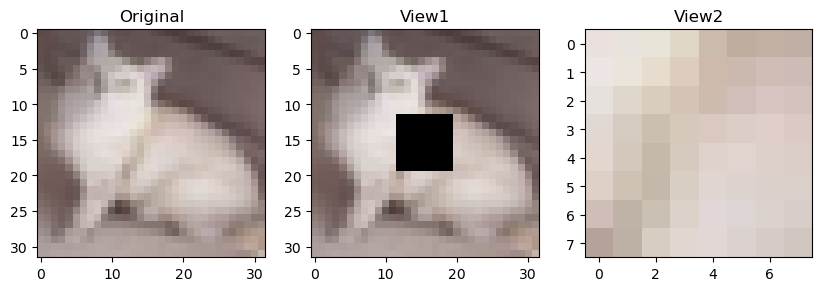

In [59]:
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(context.squeeze(0).permute(1,2,0))
plt.title("View1")

plt.subplot(1,3,3)
plt.imshow(target.squeeze(0).permute(1,2,0))
plt.title("View2")

plt.show()

# 16. Representation Similarity Checks

In [60]:
import torch.nn.functional as F

similarity = F.cosine_similarity(
    z1,
    z2,
    dim=1
)

print(similarity)

tensor([-0.1833], grad_fn=<SumBackward1>)


In [61]:
print(context.shape)
print(target.shape)

torch.Size([1, 3, 32, 32])
torch.Size([1, 3, 8, 8])


In [62]:
print("z1")
print(z1[0][:10])

print()

print("z2")
print(z2[0][:10])

print()

print("pred_z2")
print(pred_z2[0][:10])

z1
tensor([-12.8386,  -0.5940,  -0.1327,  15.5515,  -3.3702,   3.1705,   6.6976,
         -3.0245,   0.4847,  -3.6585], grad_fn=<SliceBackward0>)

z2
tensor([ 0.8036,  0.1649,  0.4132, -0.0444,  0.3946, -0.2325, -0.1105,  0.0501,
         0.0063,  0.6420])

pred_z2
tensor([ 37.7056,  10.2360,  17.5198,  -3.4579,  24.1509, -12.4261,  -5.9398,
          1.0075,  -1.7847,  32.3344], grad_fn=<SliceBackward0>)


In [63]:
print("z1 shape:", z1.shape)
print("z2 shape:", z2.shape)
print("pred_z2 shape:", pred_z2.shape)

print()

print("z2 norm:", z2.norm(dim=1))
print("pred_z2 norm:", pred_z2.norm(dim=1))

print()

print(
    "cosine similarity:",
    F.cosine_similarity(pred_z2, z2, dim=1)
)

z1 shape: torch.Size([1, 128])
z2 shape: torch.Size([1, 128])
pred_z2 shape: torch.Size([1, 128])

z2 norm: tensor([5.1152])
pred_z2 norm: tensor([258.0777], grad_fn=<LinalgVectorNormBackward0>)

cosine similarity: tensor([0.9921], grad_fn=<SumBackward1>)


In [65]:
pred_z2 = F.normalize(pred_z2, dim=1)
z2 = F.normalize(z2, dim=1)

loss = 1 - F.cosine_similarity(
    pred_z2,
    z2,
    dim=1
).mean()

In [67]:
print(pred_z2)
print(z2)

tensor([[ 0.1461,  0.0397,  0.0679, -0.0134,  0.0936, -0.0481, -0.0230,  0.0039,
         -0.0069,  0.1253,  0.0418,  0.0909,  0.0796,  0.1085, -0.0394, -0.0101,
         -0.0340,  0.1144, -0.0464, -0.0841,  0.0707,  0.0673, -0.0472,  0.0881,
          0.0191,  0.0318, -0.0793, -0.0441,  0.0260, -0.0195,  0.1017,  0.1364,
          0.0091,  0.0098, -0.0765,  0.0458,  0.0720,  0.0466, -0.0080,  0.1752,
          0.1302, -0.0532,  0.1052,  0.0449, -0.1481,  0.0258, -0.0596,  0.0222,
          0.0626, -0.2180, -0.1123,  0.0196, -0.0251, -0.0895,  0.1216,  0.2376,
         -0.0270, -0.0300, -0.1478,  0.1616, -0.0914,  0.0394,  0.1134, -0.0602,
          0.0278, -0.0499,  0.0928,  0.1217, -0.0418, -0.0229, -0.0651, -0.1042,
         -0.0130,  0.0421, -0.1208, -0.0605, -0.0171,  0.0385, -0.0985,  0.0210,
          0.0588, -0.0951, -0.0604,  0.0729, -0.1025,  0.1809,  0.0162, -0.0977,
          0.0066, -0.0307,  0.0802,  0.0174, -0.1194,  0.0069,  0.0729, -0.1595,
         -0.1049,  0.0557, -

In [66]:
print(pred_z2.norm(dim=1))
print(z2.norm(dim=1))

tensor([1.], grad_fn=<LinalgVectorNormBackward0>)
tensor([1.])
